# SPTcl-IRAGN Empirical Corner Plot
Benjamin Floyd

Presents a publication version of the empirical results

In [1]:
import h5py
import emcee
import re
import numpy as np
import matplotlib.pyplot as plt
from pygtc import plotGTC
import corner
import arviz as az

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
# Read in the chain that we want
file_name = 'Data_Repository/Project_Data/SPT-IRAGN/MCMC/SPT_Data/Chains/SPTcl-IRAGN_empirical.h5'
with h5py.File(file_name, 'r') as f:
    chain_names = list(f.keys())
chain_names

['SPTcl-IRAGN_empirical',
 'SPTcl-IRAGN_empirical_shaped_eta_-1',
 'SPTcl-IRAGN_empirical_shaped_eta_-2',
 'SPTcl-IRAGN_empirical_shaped_eta_-3',
 'SPTcl-IRAGN_empirical_shaped_eta_-4',
 'SPTcl-IRAGN_empirical_shaped_eta_-5',
 'SPTcl-IRAGN_empirical_shaped_eta_0',
 'SPTcl-IRAGN_empirical_shaped_eta_1',
 'SPTcl-IRAGN_empirical_shaped_eta_2',
 'SPTcl-IRAGN_empirical_shaped_eta_3',
 'SPTcl-IRAGN_empirical_shaped_eta_4',
 'SPTcl-IRAGN_empirical_shaped_eta_5',
 'SPTcl-IRAGN_empirical_wide_eta',
 'SPTcl-IRAGN_empirical_z1_wide_eta',
 'SPTcl-IRAGN_shaped_eta_prior']

In [3]:
# Select the chains we want to plot
# chain_names = ['SPTcl-IRAGN_empirical', 'SPTcl-IRAGN_shaped_eta_prior']
chain_names = [chain_name for chain_name in chain_names if 'empirical_shaped_eta_' in chain_name]

# Read in the datasets
samplers = {chain_name: emcee.backends.HDFBackend(filename=file_name, name=chain_name) for chain_name in chain_names}

In [4]:
# Extract the flattened chains
flattened_samples = []
for chain_name, sampler in samplers.items():
    # Get the dimensions of the chain
    nsteps, nwalkers, ndim = sampler.get_chain().shape
    
    # Get the autocorrelation time for determining the burn-in
    try:
        tau_est = sampler.get_autocorr_time()
        tau = np.mean(tau_est)
    
        burnin = int(3 * tau)
    except emcee.autocorr.AutocorrError:
        tau_est = sampler.get_autocorr_time(quiet=True)
        tau = np.mean(tau_est)
    
        burnin = int(nsteps // 3)
    
    flat_samples = sampler.get_chain(discard=burnin, thin=1, flat=True)
    flattened_samples.append(flat_samples)

The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 2000;
tau: [ 187.48653767  247.86518317 2370.69429392 2422.8345982   688.8940057
  481.74663758]


In [5]:
# Parameter names
labels = [r'$\theta$', r'$\eta$', r'$\zeta$', r'$\beta$', r'$r_c$', r'$C_0$']

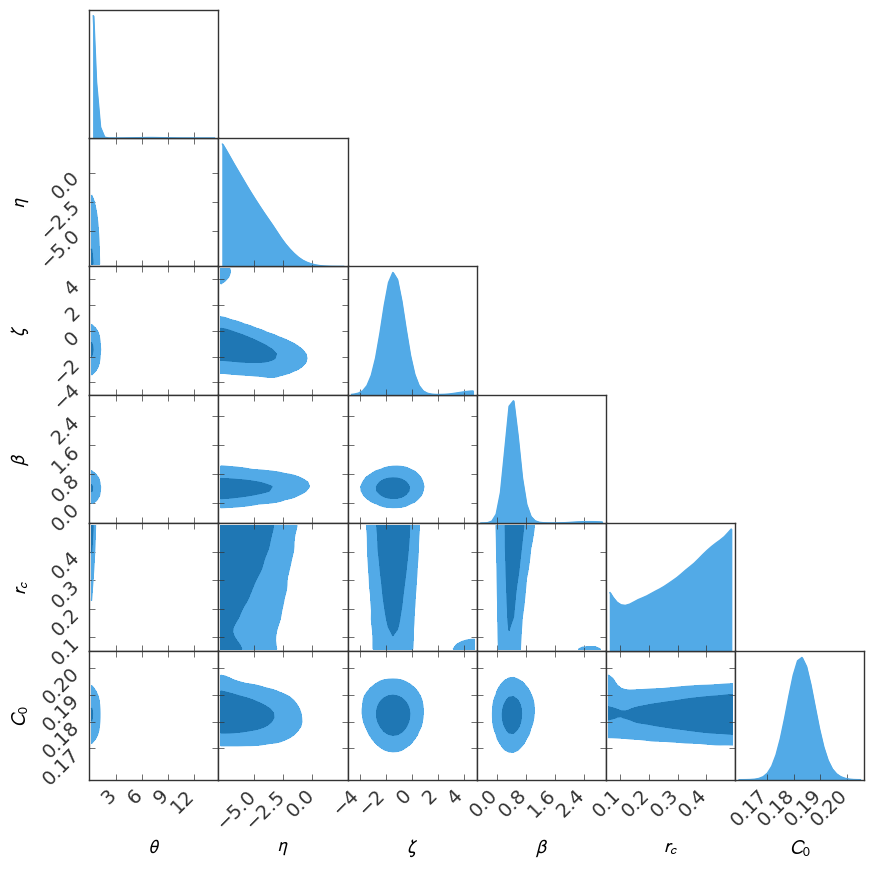

In [6]:
fig = plotGTC(chains=flattened_samples[0], paramNames=labels, figureSize=10, customTickFont={'family': 'sans-serif', 'size': 14}, customLabelFont={'family': 'sans-serif', 'size': 14}, customLegendFont={'family': 'sans-serif', 'size': 14}, plotName='Data_Repository/Project_Data/SPT-IRAGN/Publication_Plots/SPTcl-IRAGN_empirical_bad-eta.pdf')

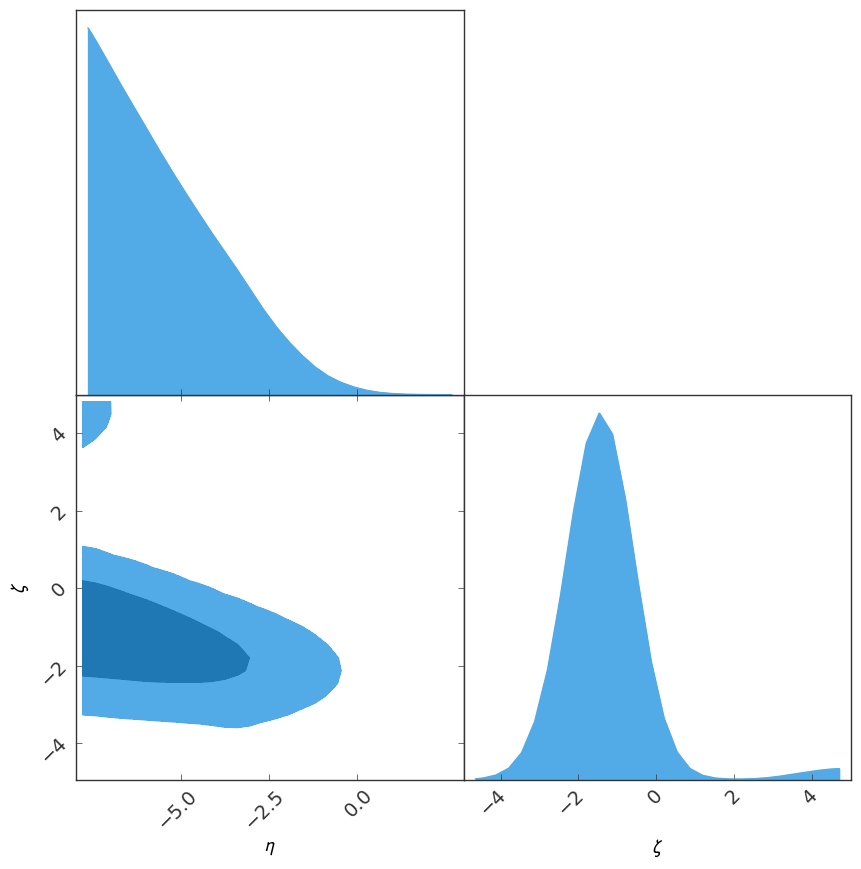

In [8]:
fig = plotGTC(chains=flattened_samples[0][:,1:3], paramNames=labels[1:3], figureSize=10, customTickFont={'family': 'sans-serif', 'size': 14}, customLabelFont={'family': 'sans-serif', 'size': 14}, customLegendFont={'family': 'sans-serif', 'size': 14}, plotName='Data_Repository/Project_Data/SPT-IRAGN/Publication_Plots/SPTcl-IRAGN_empirical_bad-eta_small_ez_corner.pdf')

In [7]:
fig = plotGTC(chains=flattened_samples, chainLabels=[r'Uninformative $\eta$ Prior', r'Shaped $\eta$ Prior'], paramNames=labels, figureSize=10, customTickFont={'family': 'sans-serif', 'size': 14}, customLabelFont={'family': 'sans-serif', 'size': 14}, customLegendFont={'family': 'sans-serif', 'size': 14}, plotName='Data_Repository/Project_Data/SPT-IRAGN/Publication_Plots/SPTcl-IRAGN_empirical_eta-prior_comparison.pdf')

AssertionError: chainLabels mismatch with number of chains

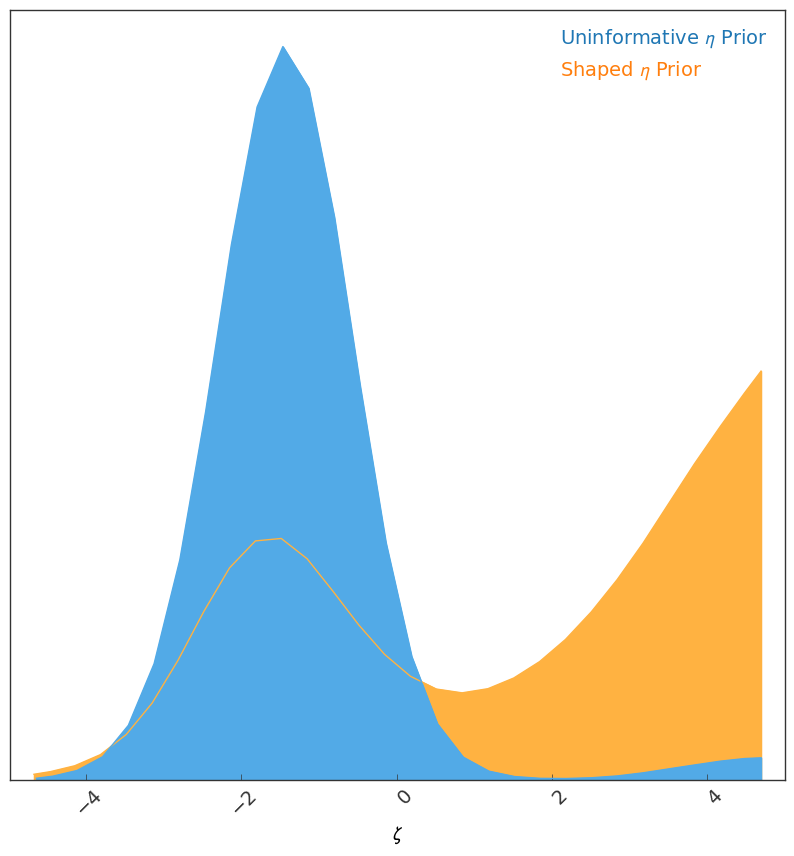

In [10]:
flattened_samples_zeta_only = [np.array([sample[:, 2]]).T for sample in flattened_samples]
fig = plotGTC(chains=flattened_samples_zeta_only, chainLabels=[r'Uninformative $\eta$ Prior', r'Shaped $\eta$ Prior'], paramNames=labels[2], figureSize=10, customTickFont={'family': 'sans-serif', 'size': 14}, customLabelFont={'family': 'sans-serif', 'size': 14}, customLegendFont={'family': 'sans-serif', 'size': 14}, plotName='Data_Repository/Project_Data/SPT-IRAGN/Publication_Plots/SPTcl-IRAGN_empirical_zeta_posterior.pdf', doOnly1dPlot=True)

In [6]:
eta_value = re.compile(r'-?\d')
chain_labels = [fr'$\eta$ prior: $\hat{{\eta}} = {eta_value.search(chain_name).group(0)} \pm 10$' for chain_name in chain_names]

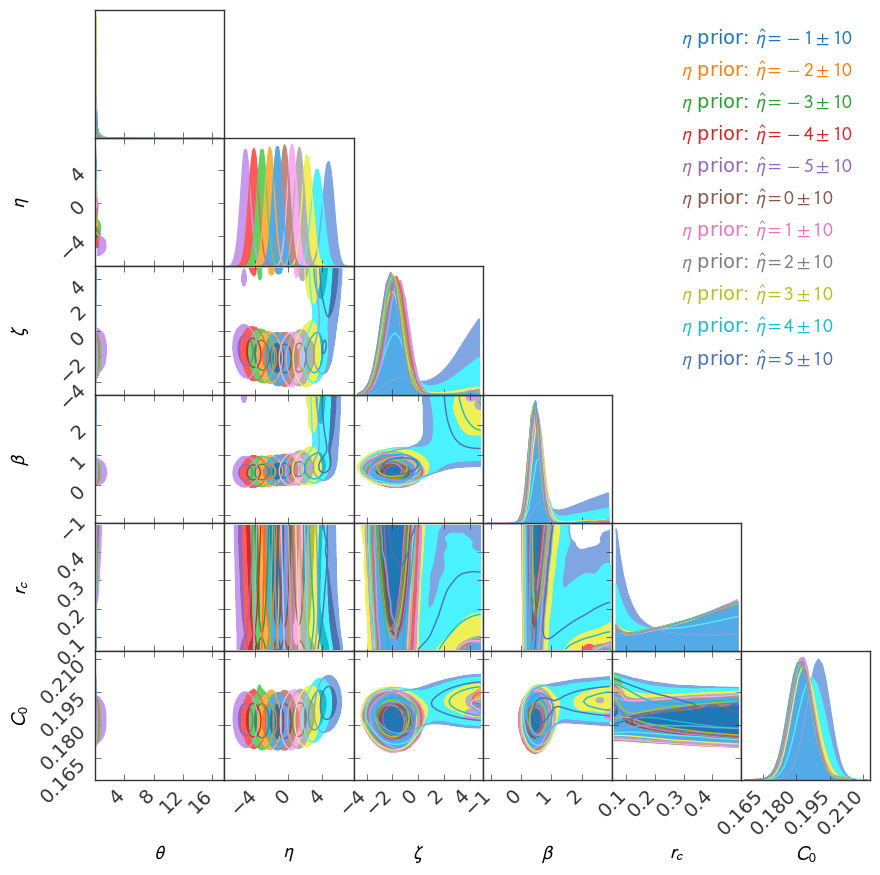

In [7]:
fig = plotGTC(chains=flattened_samples, chainLabels=chain_labels, paramNames=labels, figureSize=10, customTickFont={'family': 'sans-serif', 'size': 14}, customLabelFont={'family': 'sans-serif', 'size': 14}, customLegendFont={'family': 'sans-serif', 'size': 14}, plotName='Data_Repository/Project_Data/SPT-IRAGN/MCMC/SPT_Data/Plots/Final/Corner_plot_informed_eta_prior_comparison.pdf')